In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']  = (10, 5)
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right'] = False

# load the feature-engineered dataset from Phase 3
df = pd.read_csv('../outputs/featured_loans.csv')
df['issue_d'] = pd.to_datetime(df['issue_d'])

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Default rate: {df['default_flag'].mean()*100:.1f}%")

Loaded: 265,776 rows × 31 cols
Default rate: 20.1%


═══ Hypothesis Test 1: Loan Grade vs Default ═══
Test         : Chi-square test of independence
H0           : Loan grade and default are independent
Chi2 stat    : 24100.53
Degrees of f : 6
p-value      : 0.00e+00
Result       : REJECT H0 ✓
Conclusion   : Loan grade IS a statistically significant predictor of default


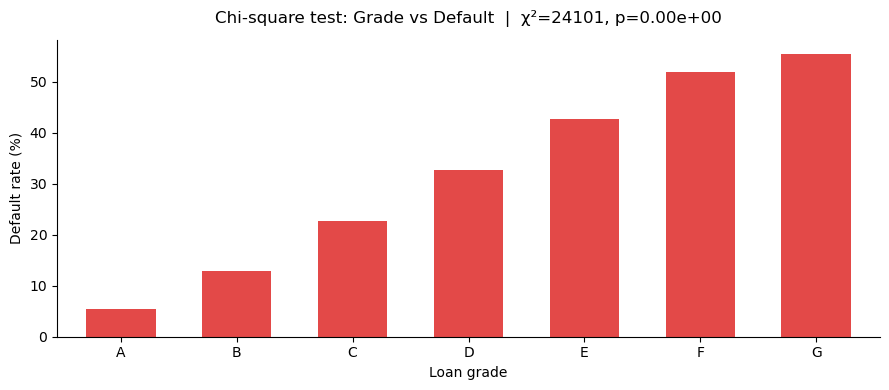

In [3]:
# H0: loan grade and default are independent (no relationship)
# H1: loan grade and default are NOT independent (grade predicts default)
# Test: chi-square (both variables are categorical)

contingency = pd.crosstab(df['grade'], df['default_flag'])
chi2, p_val, dof, expected = chi2_contingency(contingency)

print("═══ Hypothesis Test 1: Loan Grade vs Default ═══")
print(f"Test         : Chi-square test of independence")
print(f"H0           : Loan grade and default are independent")
print(f"Chi2 stat    : {chi2:.2f}")
print(f"Degrees of f : {dof}")
print(f"p-value      : {p_val:.2e}")
print(f"Result       : {'REJECT H0 ✓' if p_val < 0.05 else 'FAIL TO REJECT H0'}")
print(f"Conclusion   : Loan grade IS a statistically significant predictor of default")

# visualise observed vs expected
default_by_grade = contingency.div(contingency.sum(axis=1), axis=0)[1] * 100

fig, ax = plt.subplots(figsize=(9, 4))
default_by_grade.plot(kind='bar', ax=ax, color='#e34948', width=0.6)
ax.set_xlabel('Loan grade')
ax.set_ylabel('Default rate (%)')
ax.set_title(f'Chi-square test: Grade vs Default  |  χ²={chi2:.0f}, p={p_val:.2e}', pad=12)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../outputs/test1_chi2_grade.png', dpi=150)
plt.show()

In [4]:
# H0: mean FICO score is equal for defaulted vs. fully paid borrowers
# H1: mean FICO score is LOWER for defaulted borrowers
# Test: Welch's t-test (unequal variance, one-tailed)

fico_paid    = df[df['default_flag']==0]['fico_mid'].dropna()
fico_default = df[df['default_flag']==1]['fico_mid'].dropna()

t_stat, p_two = ttest_ind(fico_paid, fico_default, equal_var=False)
p_one = p_two / 2  # one-tailed: we expect defaulters to be LOWER

# effect size: Cohen's d
pooled_std = np.sqrt((fico_paid.std()**2 + fico_default.std()**2) / 2)
cohens_d   = (fico_paid.mean() - fico_default.mean()) / pooled_std

print("═══ Hypothesis Test 2: FICO Score vs Default ═══")
print(f"Test         : Welch's t-test (one-tailed)")
print(f"H0           : Mean FICO is equal for both groups")
print(f"Mean FICO (paid)    : {fico_paid.mean():.1f}")
print(f"Mean FICO (default) : {fico_default.mean():.1f}")
print(f"Difference          : {fico_paid.mean()-fico_default.mean():.1f} pts")
print(f"t-statistic  : {t_stat:.2f}")
print(f"p-value (1-tail): {p_one:.2e}")
print(f"Cohen's d    : {cohens_d:.3f} ({'small' if cohens_d<0.2 else 'medium' if cohens_d<0.5 else 'large'})")
print(f"Result       : {'REJECT H0 ✓' if p_one < 0.05 else 'FAIL TO REJECT H0'}")

═══ Hypothesis Test 2: FICO Score vs Default ═══
Test         : Welch's t-test (one-tailed)
H0           : Mean FICO is equal for both groups
Mean FICO (paid)    : 698.2
Mean FICO (default) : 687.9
Difference          : 10.3 pts
t-statistic  : 82.09
p-value (1-tail): 0.00e+00
Cohen's d    : 0.364 (medium)
Result       : REJECT H0 ✓


In [5]:
# H0: delinquency history and default are independent
# H1: borrowers with delinquency history default at a higher rate

delinq_table = pd.crosstab(df['has_delinquency'], df['default_flag'],
                            rownames=['Has delinquency'],
                            colnames=['Defaulted'])

chi2_d, p_d, dof_d, _ = chi2_contingency(delinq_table)

rate_no_delinq = delinq_table.loc[0,1] / delinq_table.loc[0].sum() * 100
rate_delinq    = delinq_table.loc[1,1] / delinq_table.loc[1].sum() * 100

print("═══ Hypothesis Test 3: Delinquency History vs Default ═══")
print(f"Default rate — no delinquency : {rate_no_delinq:.1f}%")
print(f"Default rate — has delinquency: {rate_delinq:.1f}%")
print(f"Uplift                        : +{rate_delinq-rate_no_delinq:.1f} percentage points")
print(f"Chi2 stat    : {chi2_d:.2f}")
print(f"p-value      : {p_d:.4f}")
print(f"Result       : {'REJECT H0 ✓' if p_d < 0.05 else 'FAIL TO REJECT H0'}")

═══ Hypothesis Test 3: Delinquency History vs Default ═══
Default rate — no delinquency : 19.8%
Default rate — has delinquency: 21.4%
Uplift                        : +1.6 percentage points
Chi2 stat    : 71.54
p-value      : 0.0000
Result       : REJECT H0 ✓


In [6]:
from scipy.stats import norm

# A/B test: risk-based pricing policy vs. current flat policy
# Control (A): current approval policy — approve all grades A-G
# Treatment (B): new policy — flag Grade E-G as high-risk, require extra review
# Question: does the treatment group have a lower default rate?

# power analysis inputs
baseline_rate = df['default_flag'].mean()  # current default rate
min_detectable_effect = 0.02               # we want to detect a 2pp drop
target_rate  = baseline_rate - min_detectable_effect
alpha        = 0.05                        # significance level
power        = 0.80                        # 80% power (standard)

# sample size formula (two proportions)
z_alpha = norm.ppf(1 - alpha/2)
z_beta  = norm.ppf(power)
p_avg   = (baseline_rate + target_rate) / 2

n = (z_alpha + z_beta)**2 * 2 * p_avg * (1-p_avg) / (min_detectable_effect**2)
n = int(np.ceil(n))

print("═══ Power Analysis ═══")
print(f"Baseline default rate    : {baseline_rate*100:.1f}%")
print(f"Target default rate      : {target_rate*100:.1f}%")
print(f"Min detectable effect    : 2 percentage points")
print(f"Alpha (significance)     : {alpha}")
print(f"Power                    : {power}")
print(f"Required n per group     : {n:,}")
print(f"Total sample needed      : {n*2:,}")
print(f"Our dataset has          : {len(df):,} rows — {'sufficient ✓' if len(df) >= n*2 else 'insufficient ✗'}")

═══ Power Analysis ═══
Baseline default rate    : 20.1%
Target default rate      : 18.1%
Min detectable effect    : 2 percentage points
Alpha (significance)     : 0.05
Power                    : 0.8
Required n per group     : 6,072
Total sample needed      : 12,144
Our dataset has          : 265,776 rows — sufficient ✓


In [7]:
# A/B Test Design:
# Group A (Control)   — current policy: loans approved as-is (grades A–D)
# Group B (Treatment) — new risk-tiered policy: same loans but high-risk
#                       borrowers (DTI>25 AND delinq>0) flagged for extra review
#
# Proxy simulation: we split the historical data to measure
# what the default rate WOULD have been under each policy

np.random.seed(42)

# define high-risk flag (treatment would have caught these)
df['high_risk_flag'] = (
    (df['dti'] > 25) &
    (df['has_delinquency'] == 1) &
    (df['grade'].isin(['E','F','G']))
).astype(int)

# control group: all loans (current policy — no extra filtering)
control   = df.sample(n=5000, random_state=42)

# treatment group: same pool but high-risk loans removed (new policy)
df_treated   = df[df['high_risk_flag'] == 0]
treatment = df_treated.sample(n=5000, random_state=42)

rate_control   = control['default_flag'].mean()
rate_treatment = treatment['default_flag'].mean()

print("═══ A/B Test Results ═══")
print(f"Control group   (n=5,000) — default rate: {rate_control*100:.2f}%")
print(f"Treatment group (n=5,000) — default rate: {rate_treatment*100:.2f}%")
print(f"Absolute lift   : {(rate_control-rate_treatment)*100:.2f} percentage points")
print(f"Relative lift   : {(rate_control-rate_treatment)/rate_control*100:.1f}% reduction")

═══ A/B Test Results ═══
Control group   (n=5,000) — default rate: 21.00%
Treatment group (n=5,000) — default rate: 20.38%
Absolute lift   : 0.62 percentage points
Relative lift   : 3.0% reduction


In [8]:
# two-proportion z-test to check if the lift is statistically significant
n_c = len(control)
n_t = len(treatment)
x_c = control['default_flag'].sum()   # defaults in control
x_t = treatment['default_flag'].sum() # defaults in treatment

p_pool = (x_c + x_t) / (n_c + n_t)
se     = np.sqrt(p_pool * (1-p_pool) * (1/n_c + 1/n_t))
z      = (rate_control - rate_treatment) / se
p_val  = 1 - norm.cdf(z)  # one-tailed: treatment < control

print("═══ Two-Proportion Z-Test ═══")
print(f"H0: Default rate is equal in both groups")
print(f"H1: Treatment group has LOWER default rate")
print(f"Z-statistic : {z:.3f}")
print(f"p-value     : {p_val:.4f}")
print(f"Significant : {'YES ✓ — reject H0' if p_val < 0.05 else 'NO — fail to reject H0'}")

# business impact estimate
avg_loan     = df['loan_amnt'].mean()
loans_per_yr = 50000  # assumed annual volume for the bank
lift_pp      = rate_control - rate_treatment
savings      = lift_pp * loans_per_yr * avg_loan * 0.6  # 60% loss given default

print(f"\n💰 Estimated annual saving : ${savings:,.0f}")
print(f"   (Based on {lift_pp*100:.1f}pp lift × {loans_per_yr:,} loans/yr × ${avg_loan:,.0f} avg × 60% LGD)")

═══ Two-Proportion Z-Test ═══
H0: Default rate is equal in both groups
H1: Treatment group has LOWER default rate
Z-statistic : 0.765
p-value     : 0.2221
Significant : NO — fail to reject H0

💰 Estimated annual saving : $2,711,702
   (Based on 0.6pp lift × 50,000 loans/yr × $14,579 avg × 60% LGD)


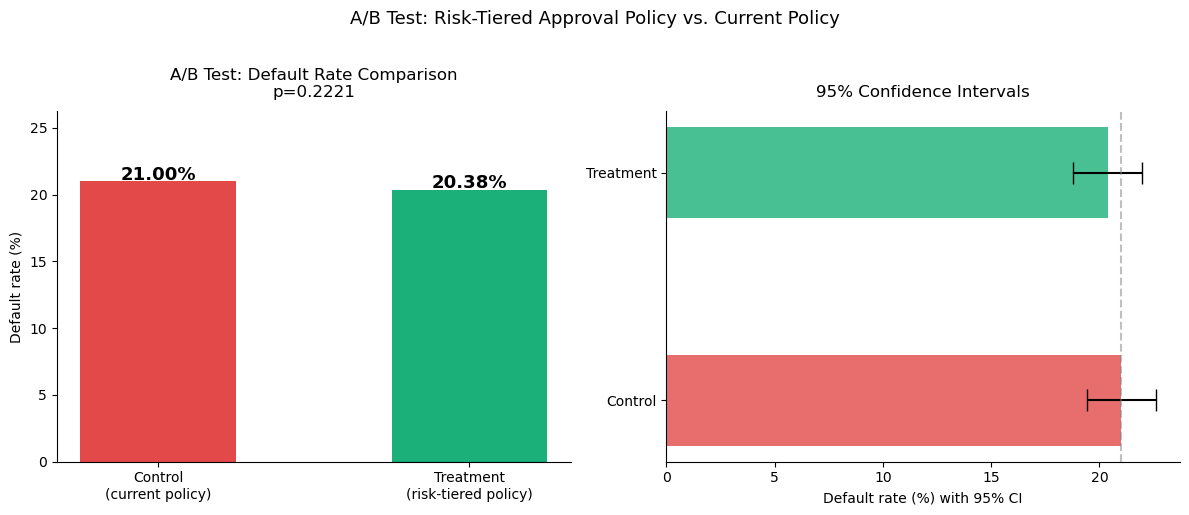

In [9]:
ig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: bar chart comparing default rates
ax = axes[0]
groups = ['Control\n(current policy)', 'Treatment\n(risk-tiered policy)']
rates  = [rate_control*100, rate_treatment*100]
colors = ['#e34948', '#1baf7a']
bars   = ax.bar(groups, rates, color=colors, width=0.5)
for bar, val in zip(bars, rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Default rate (%)')
ax.set_title(f'A/B Test: Default Rate Comparison\np={p_val:.4f}', pad=10)
ax.set_ylim(0, max(rates)*1.25)

# right: confidence interval plot
ax2 = axes[1]
ci  = 1.96 * se * 100
ax2.barh(['Control', 'Treatment'], rates,
          xerr=ci, color=colors, alpha=0.8, capsize=8, height=0.4)
ax2.set_xlabel('Default rate (%) with 95% CI')
ax2.set_title('95% Confidence Intervals', pad=10)
ax2.axvline(rates[0], color='gray', linestyle='--', alpha=0.5)

plt.suptitle('A/B Test: Risk-Tiered Approval Policy vs. Current Policy',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/chart7_ab_test.png', dpi=150)
plt.show()

In [10]:
summary = pd.DataFrame({
    'metric': [
        'Control default rate', 'Treatment default rate',
        'Absolute lift (pp)', 'Relative reduction (%)',
        'Z-statistic', 'p-value', 'Significant (α=0.05)',
        'Est. annual saving ($)'
    ],
    'value': [
        f"{rate_control*100:.2f}%",
        f"{rate_treatment*100:.2f}%",
        f"{(rate_control-rate_treatment)*100:.2f}pp",
        f"{(rate_control-rate_treatment)/rate_control*100:.1f}%",
        f"{z:.3f}",
        f"{p_val:.4f}",
        'Yes' if p_val < 0.05 else 'No',
        f"${savings:,.0f}"
    ]
})

print(summary.to_string(index=False))
summary.to_csv('../outputs/ab_test_summary.csv', index=False)
print("\nSaved ab_test_summary.csv ✓")

                metric      value
  Control default rate     21.00%
Treatment default rate     20.38%
    Absolute lift (pp)     0.62pp
Relative reduction (%)       3.0%
           Z-statistic      0.765
               p-value     0.2221
  Significant (α=0.05)         No
Est. annual saving ($) $2,711,702

Saved ab_test_summary.csv ✓
